ρI VS w

加载了 36 个数据点
Saved figure -> rho_vs_w_experiment\rho_vs_w_plot.png


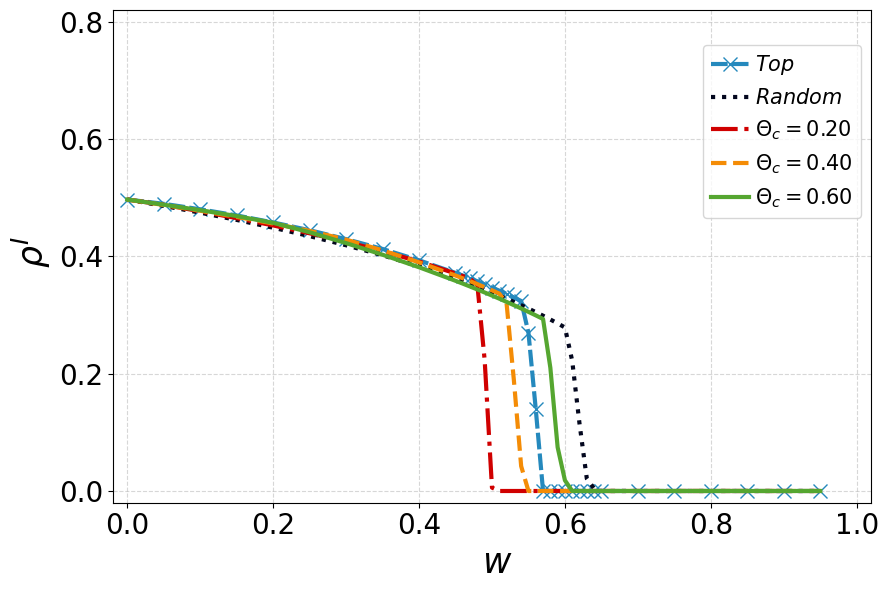

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
plot_rho_vs_w_simple.py

从 `rho_vs_w_experiment/rho_vs_w_summary.csv` 读取汇总数据，
绘制 ρ* (mean_rho) vs w_budget 的曲线，比较不同的 theta_del（Θ）与 random 对照。

输出:
  rho_vs_w_experiment/rho_vs_w_plot.png
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 配置 ----------
OUT_DIR = "rho_vs_w_experiment"            # 与运行脚本相同的输出目录
out_dir="rho_vs_w_top_experiment"

SUMMARY_FN = os.path.join(OUT_DIR, "rho_vs_w_summary.csv")
FIG_FN = os.path.join(OUT_DIR, "rho_vs_w_plot.png")

# 颜色和样式（可按需改）
colors = ['#03071e', "#d00000", '#f48c06', "#55a630",]
# colors = ['#3b1f2b', "#383961", '#5f758e', "#dbdfac",]
markers = ['o', 's', '^', 'D', 'v', 'P']
alpha_fill = 0.18
linestyles = [':', '-.', '--', '-']

# ---------- 读取数据 ----------
if not os.path.exists(SUMMARY_FN):
    raise FileNotFoundError(f"Summary file not found: {SUMMARY_FN}")

df = pd.read_csv(SUMMARY_FN)

# 兼容：有的脚本把 w 列名叫 'w' 或 'w_budget'，优先使用 w_budget
if 'w_budget' not in df.columns and 'w' in df.columns:
    df = df.rename(columns={'w': 'w_budget'})

# 检查必须列
required = {'deletion_type', 'theta_del', 'w_budget', 'mean_rho', 'std_rho'}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in summary CSV: {missing}")

# ---------- 生成用于绘图的标签列 ----------
# 如果 deletion_type 是 'random' 则标记为 'random'，否则用 Θ=xx 标签（保留两位小数）
def make_label(row):
    if str(row['deletion_type']).lower() == 'random':
        return r'$Random$'
    # 若 theta_del 为 NaN（安全起见），也标为 random
    try:
        if pd.isna(row['theta_del']):
            return 'random'
    except:
        pass
    return fr"$\Theta_c={float(row['theta_del']):.2f}$"

df['theta_label'] = df.apply(make_label, axis=1)



plt.figure(figsize=(9,6))
# ---------- 为  Top_label 绘制曲线 ----------
summary_file = os.path.join(out_dir, "rho_vs_w_top_summary.csv")

if not os.path.exists(summary_file):
    print(f"错误：找不到结果文件 {summary_file}")
    print("请先运行模拟代码生成结果文件")

# 加载数据
summary_df = pd.read_csv(summary_file)
print(f"加载了 {len(summary_df)} 个数据点")

plt.plot(summary_df['w_budget'], summary_df['mean_rho'], linestyle =(0, (4, 1)), marker='x',
                 linewidth=3, markersize=10, label=r'$Top$', color='#2589bd')


# ---------- 为每个 theta_label 绘制曲线 ----------
labels = sorted(df['theta_label'].unique(), key=lambda x:  (0 if x=='random' else 1, x))  # 把 'random' 放最前
# 按元组排序：(先按第一个元素，再按第二个元素)
# (1, 'random') → 第一
# (0, '\Theta_c=0.2') → 第二
# (0, '\Theta_c=0.4') → 第三
# (0, '\Theta_c=0.6') → 第四

for i, label in enumerate(labels):
    sub = df[df['theta_label'] == label].copy()
    if sub.empty:
        continue
    # 确保按 w_budget 升序
    sub = sub.sort_values('w_budget')
    x = sub['w_budget'].to_numpy()
    y = sub['mean_rho'].to_numpy()
    # std 列可能全为 NaN（比如重复数=1），用 0 代替
    if 'std_rho' in sub.columns:
        yerr = sub['std_rho'].fillna(0.0).to_numpy()
    else:
        yerr = np.zeros_like(y)

    color = colors[i % len(colors)]
    marker = markers[i % len(markers)]
    linestyle = linestyles[i % len(linestyles)]

    plt.plot(x, y, label=label, color=color, linestyle=linestyle, linewidth=3, )


# ---------- 图形美化 ----------
plt.xlabel(r" $w$ ", fontsize=25)
plt.ylabel(r" $ρ^I$ ", fontsize=25)
# plt.title("Steady-state prevalence ρ* vs edge removal fraction w", fontsize=14)
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 0.82)
plt.xticks(np.linspace(0,1,6), fontsize=20)
plt.yticks(np.linspace(0,0.8,5), fontsize=20)
plt.grid(alpha=0.5, linestyle='--', linewidth=0.8)

legend = plt.legend(
    loc='upper right',
    bbox_to_anchor=(1, 0.95),
    fontsize='15',
    handletextpad=0.3,    # 图标与文本的间距
    #columnspacing=1,      # 列间距（多列时有效）
    borderpad=0.4,          # 图例内边距
    # ncol=2,              # 分两列
    handlelength=1.8,    # 统一图标宽度
    columnspacing=0.5,     # 缩小列间距（默认2.0）
)
plt.tight_layout()

# ---------- 保存并显示 ----------
os.makedirs(OUT_DIR, exist_ok=True)
plt.savefig(FIG_FN, dpi=300, bbox_inches='tight')
print(f"Saved figure -> {FIG_FN}")
plt.show()
